In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import scipy.stats as stats
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [4]:
df = pd.read_csv("concrete_data.csv")
df.head(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
df.shape

(1030, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [7]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [9]:
X = df.drop(columns=['Strength'])
y = df.iloc[:,-1]

X

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [10]:
y

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Strength, Length: 1030, dtype: float64

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
# Applying Regression without any transformation
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.6275531792314848

### Cross Validation using cross_val_score

In [15]:
lr = LinearRegression()
print(np.mean(cross_val_score(lr,X,y,scoring='r2')))

0.4609940491662864


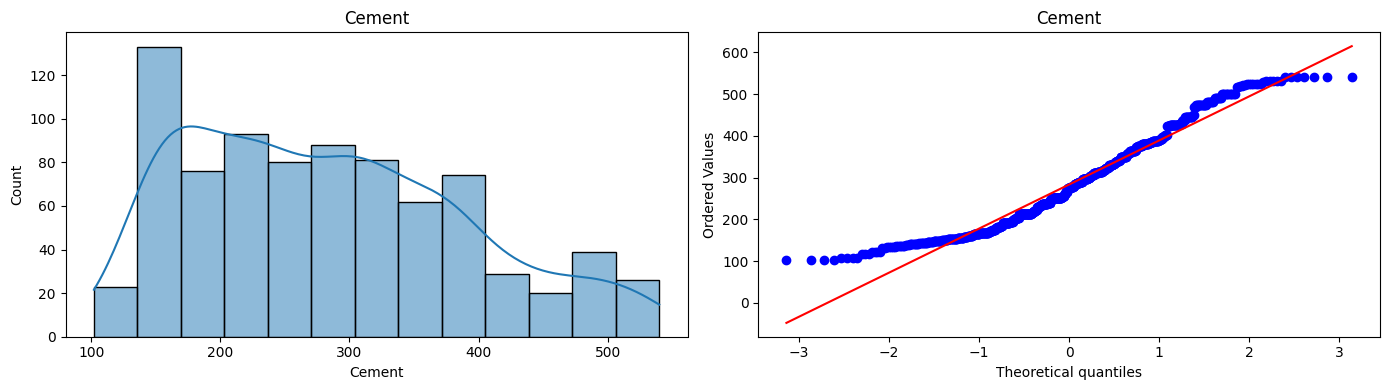

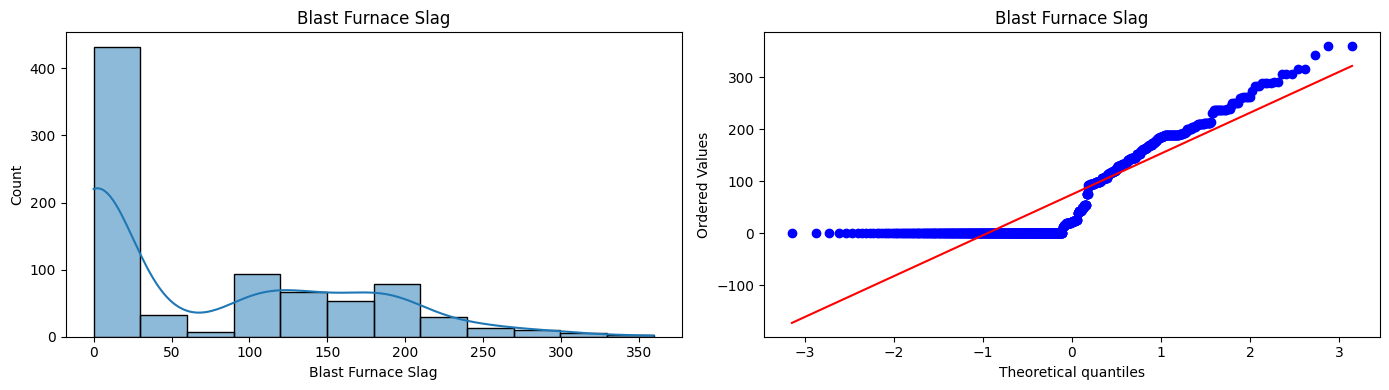

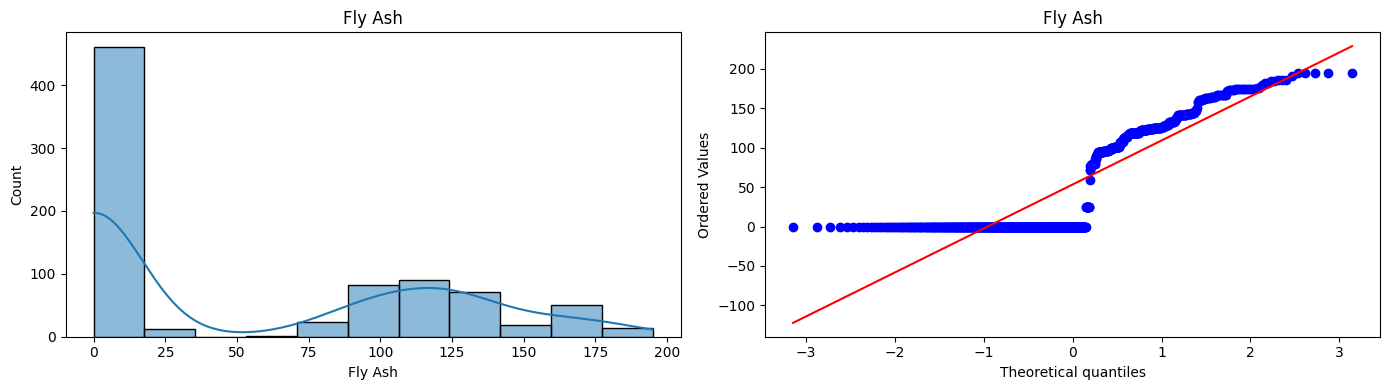

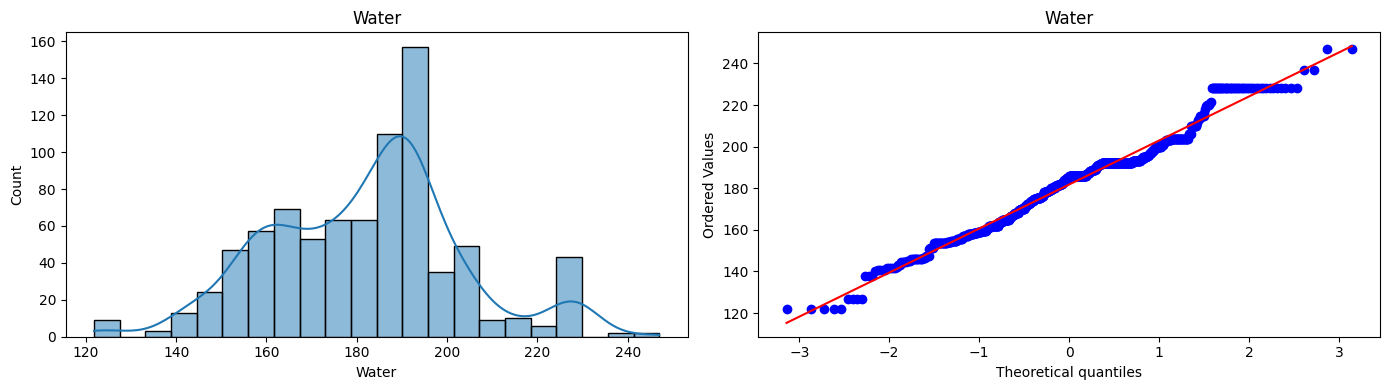

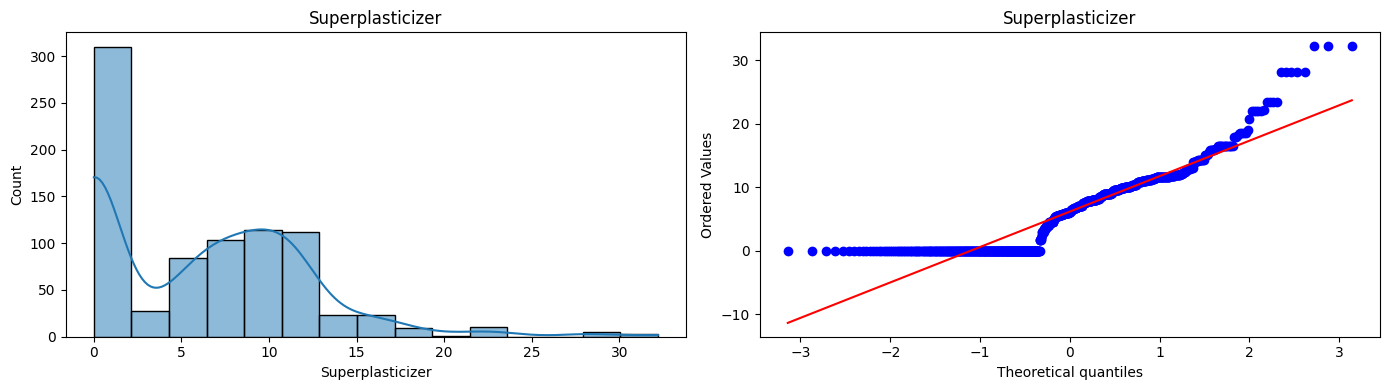

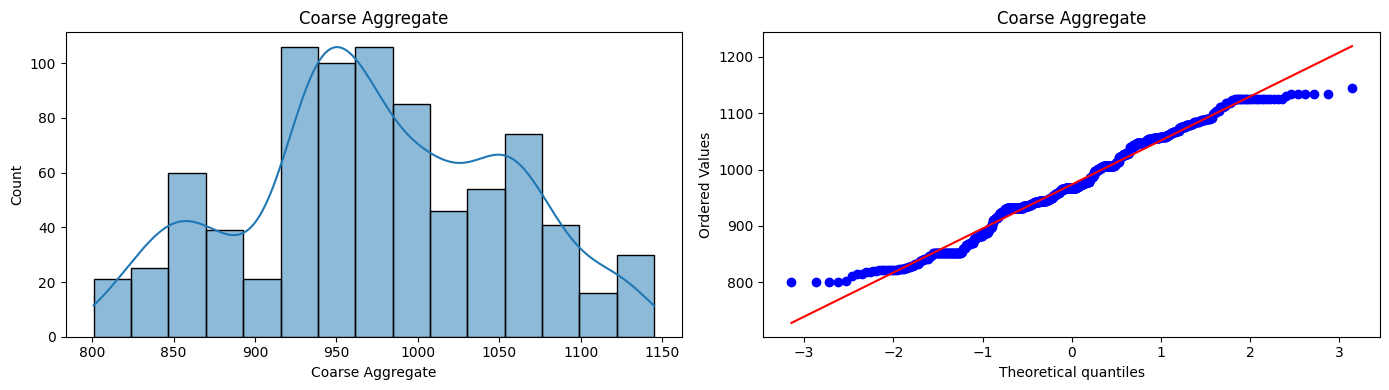

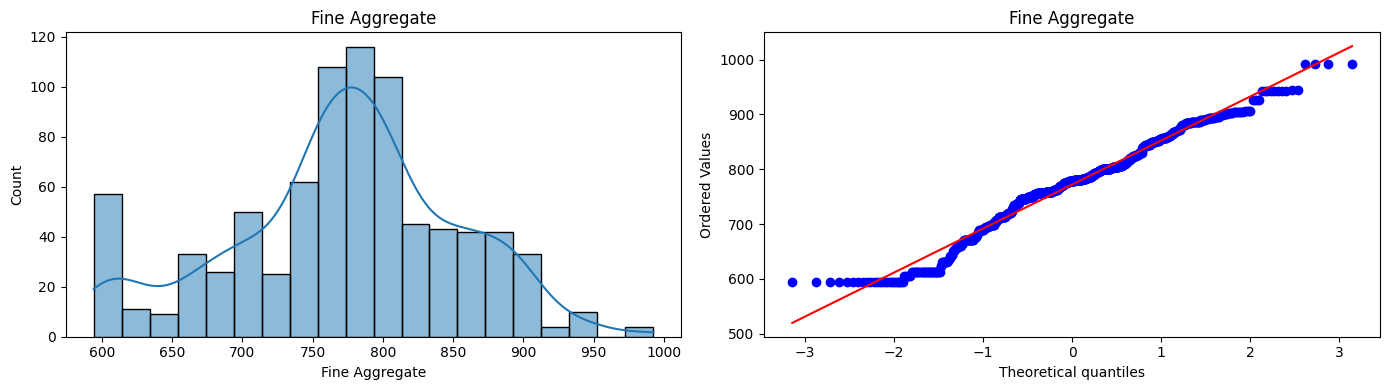

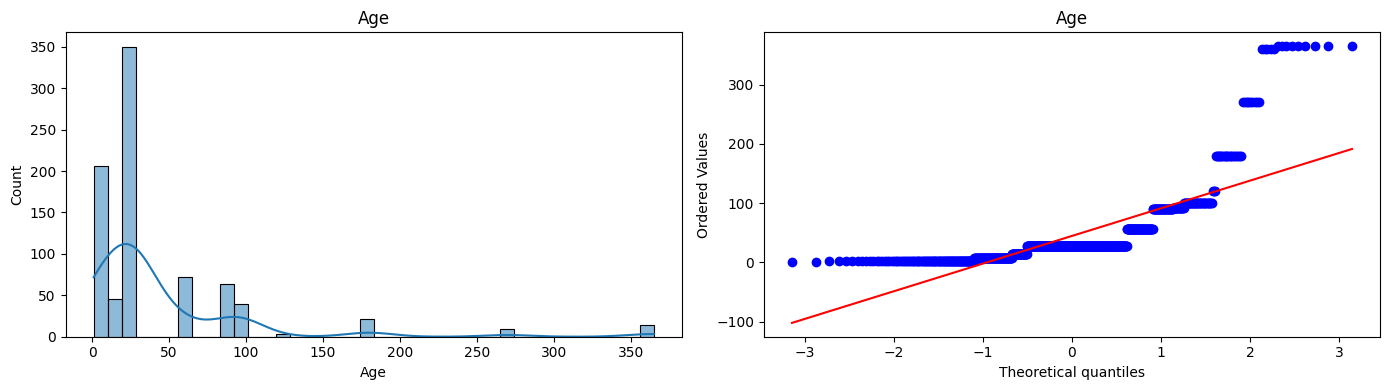

In [17]:
# plotting the distplots without any transformation

for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True)
    plt.title(col)

    #second plot
    plt.subplot(122)
    stats.probplot(X_train[col],dist='norm',plot=plt)
    plt.title(col)

    plt.tight_layout()
    plt.show()

### Applying Box-Cox transformation

In [18]:
pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test + 0.000001)

pd.DataFrame(
   { 'cols':X_train.columns,
    "box-cox-lambda":pt.lambdas_
   }
)

,cols,box-cox-lambda
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


### Applying linear Regression on  transformed data

In [19]:
lr1 = LinearRegression()
lr1.fit(X_train_transformed,y_train)

y_pred2 = lr1.predict(X_test_transformed)

r2_score(y_test,y_pred2)

0.8047825008078886

### using cross value score

In [20]:
pt1 = PowerTransformer(method='box-cox')

X_transformed = pt1.fit_transform(X + 0.000001)

np.mean(cross_val_score(lr1,X_transformed,y,scoring='r2'))

np.float64(0.6662950326831086)

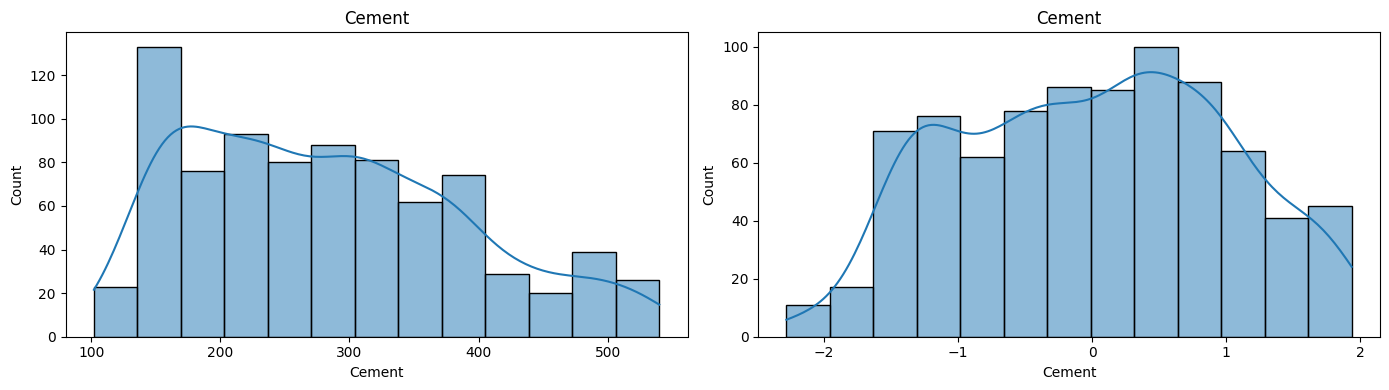

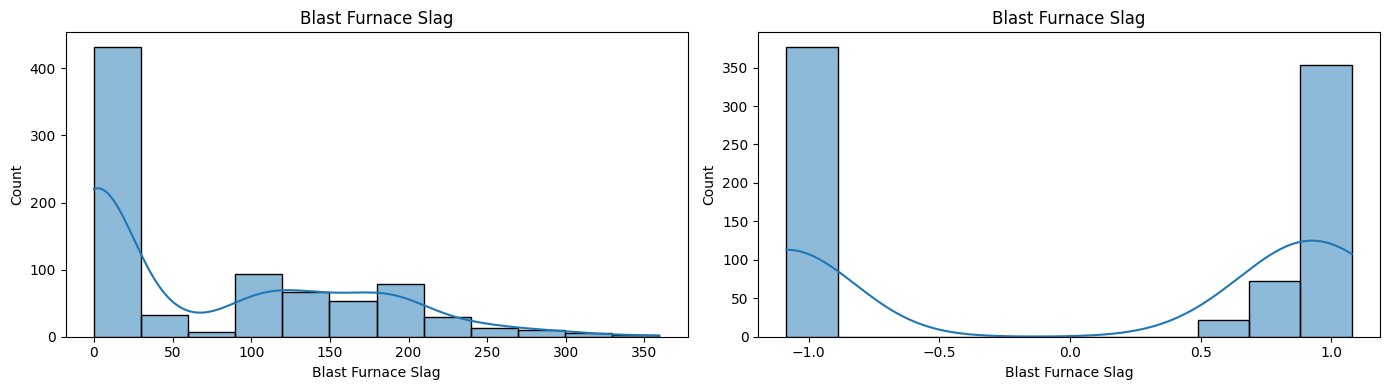

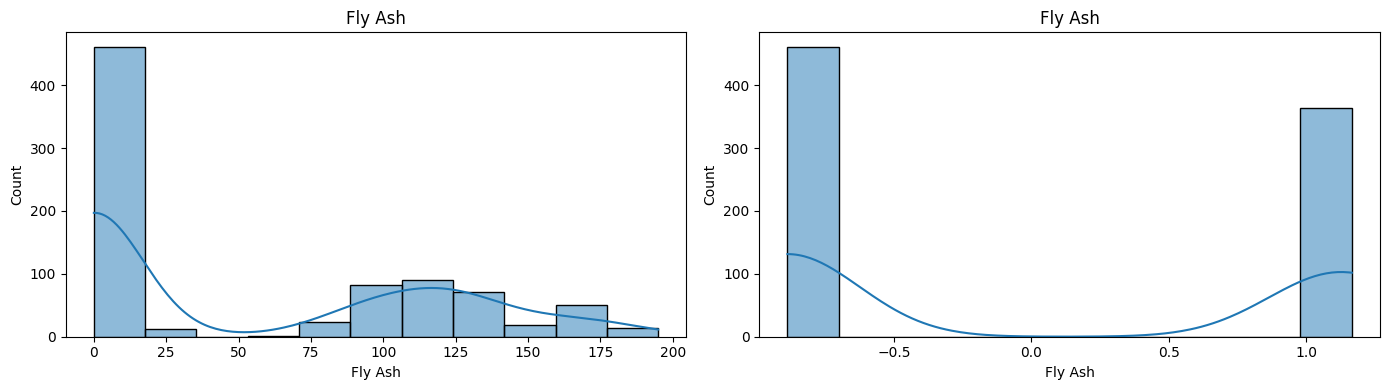

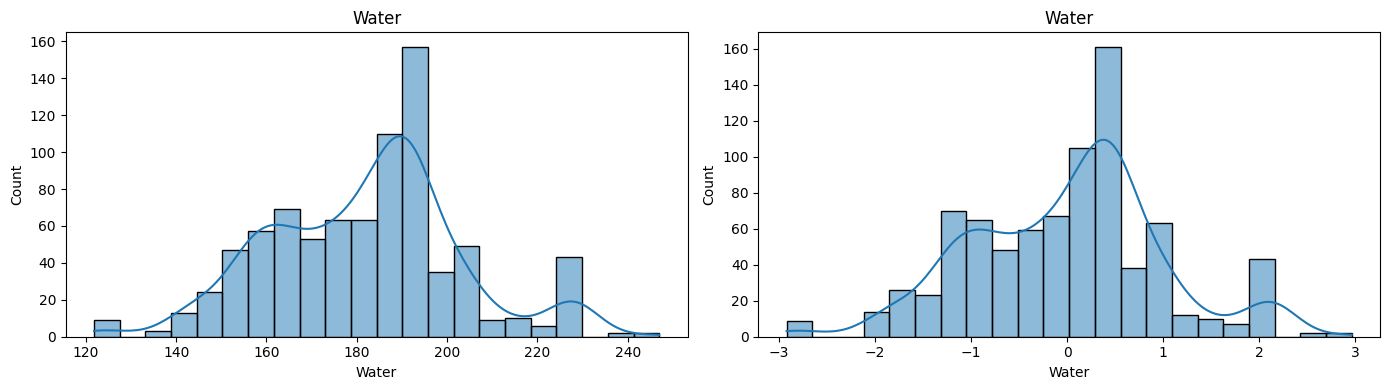

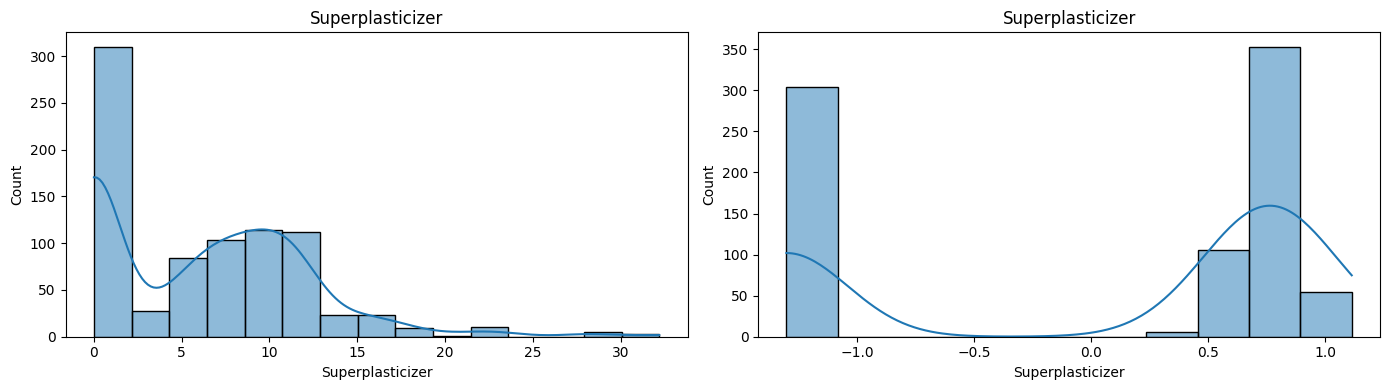

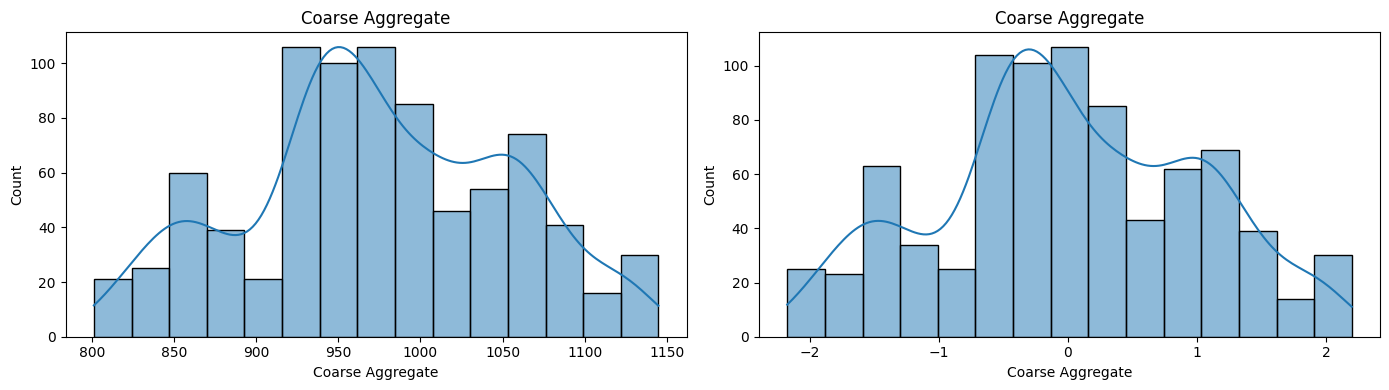

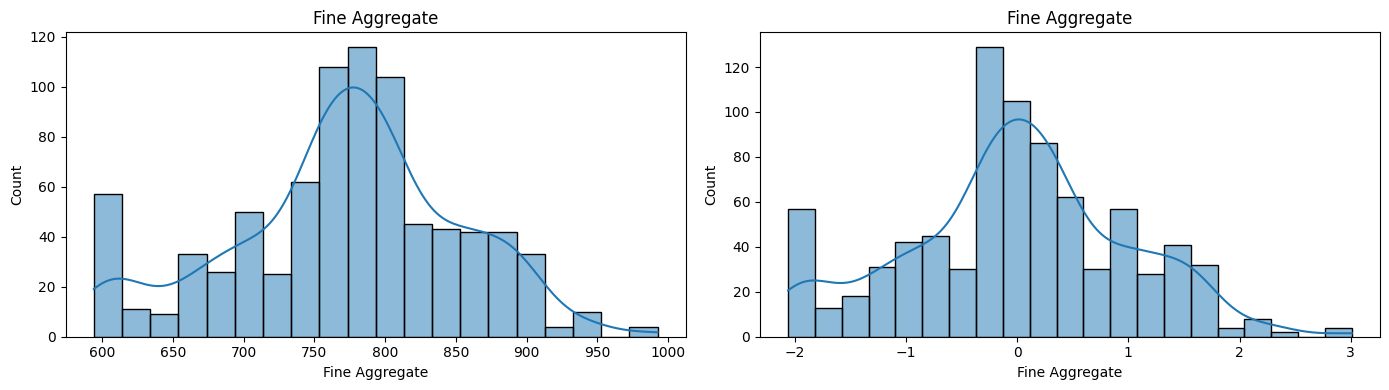

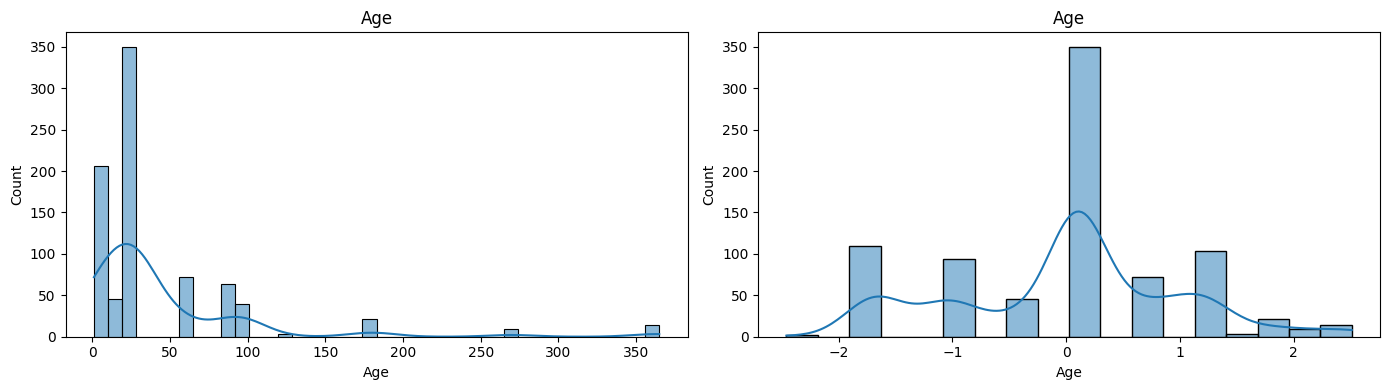

In [23]:
# Before and After comparison for Box-Cox plot

X_train_transformed =pd.DataFrame(X_train_transformed,columns=X_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True)
    plt.title(col)

    # after plot
    plt.subplot(122)
    sns.histplot(X_train_transformed[col],kde=True)
    plt.title(col)

    plt.tight_layout()
    plt.show()

### Applying Yeo-Johnson Transform

In [24]:
# pt2 = PowerTransformer() # by_default ,it is yeo-johnson transform
pt2 = PowerTransformer(method='yeo-johnson')

X_train_transformed2 = pt2.fit_transform(X_train)
X_test_transformed2 = pt2.transform(X_test)

# applying linear regression
lir = LinearRegression()

lir.fit(X_train_transformed2,y_train)
y_pred3 = lir.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame(
    {
        "cols":X_train.columns,
        "Yeo-Johnson_lambdas":pt2.lambdas_
    }
)

0.8161906511066099


,cols,Yeo-Johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


### Applying cross val score

In [26]:
pwt = PowerTransformer(method='yeo-johnson')
X_transformed2 = pwt.fit_transform(X)

lnr = LinearRegression()
np.mean(cross_val_score(lnr,X_transformed2,y,scoring='r2'))

np.float64(0.6834625126992433)

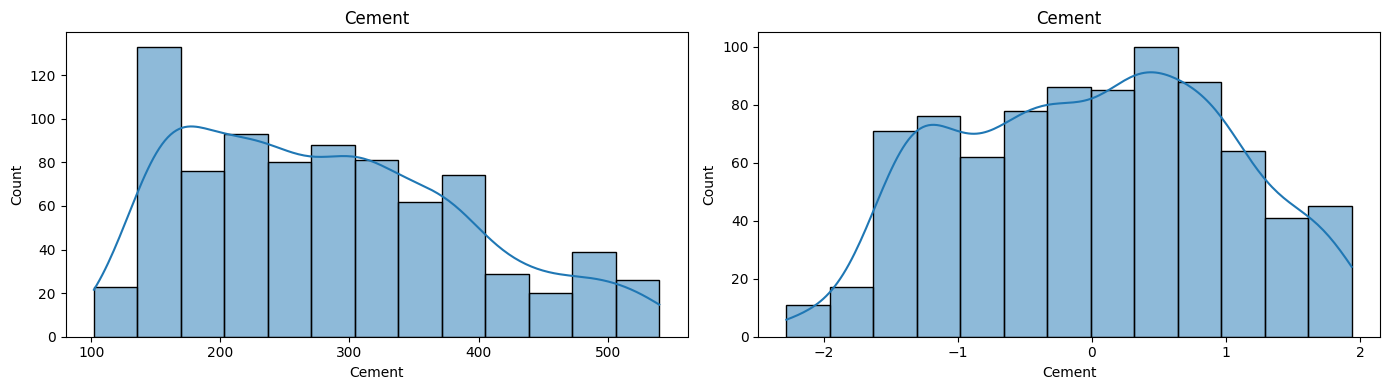

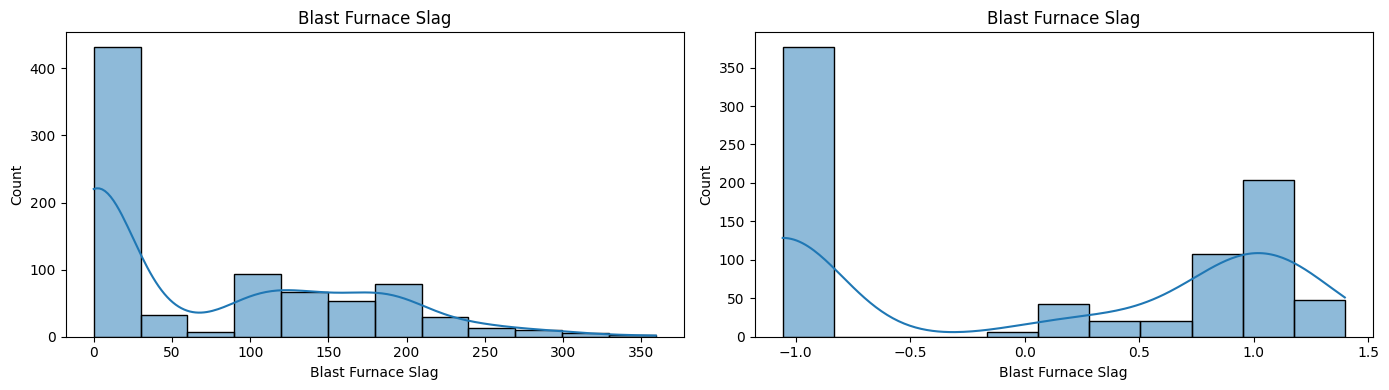

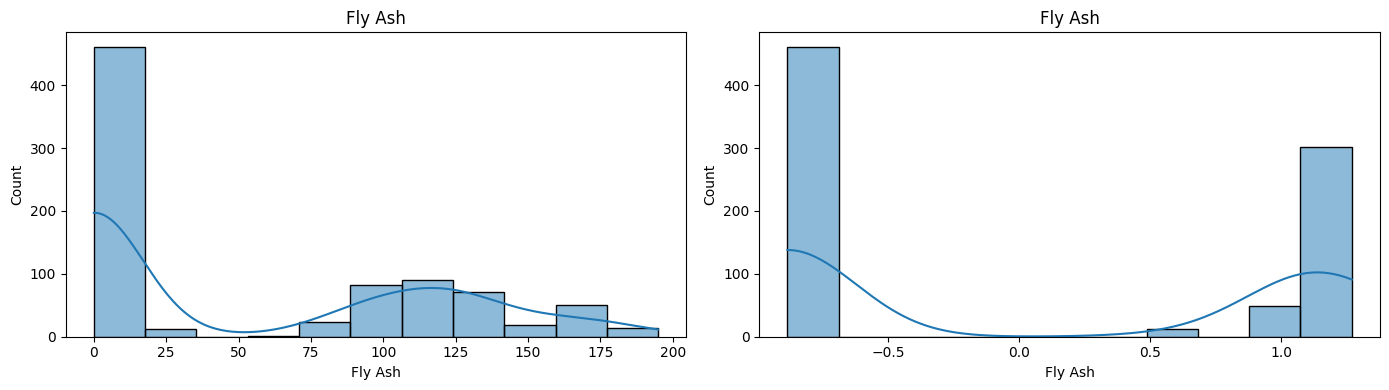

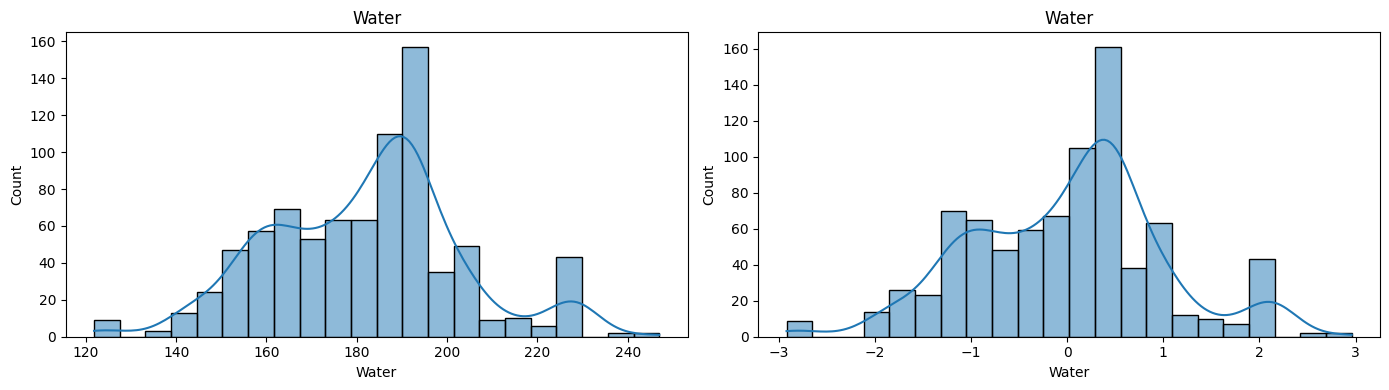

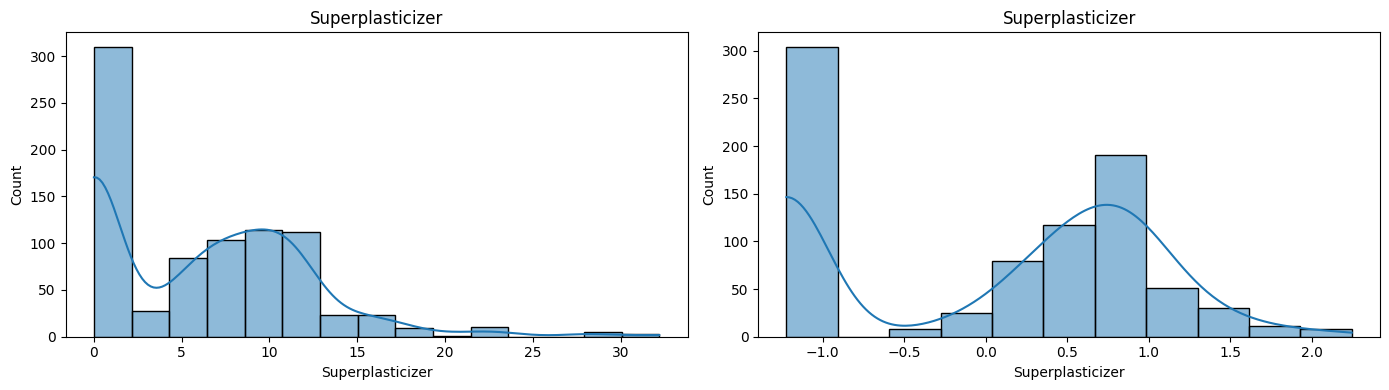

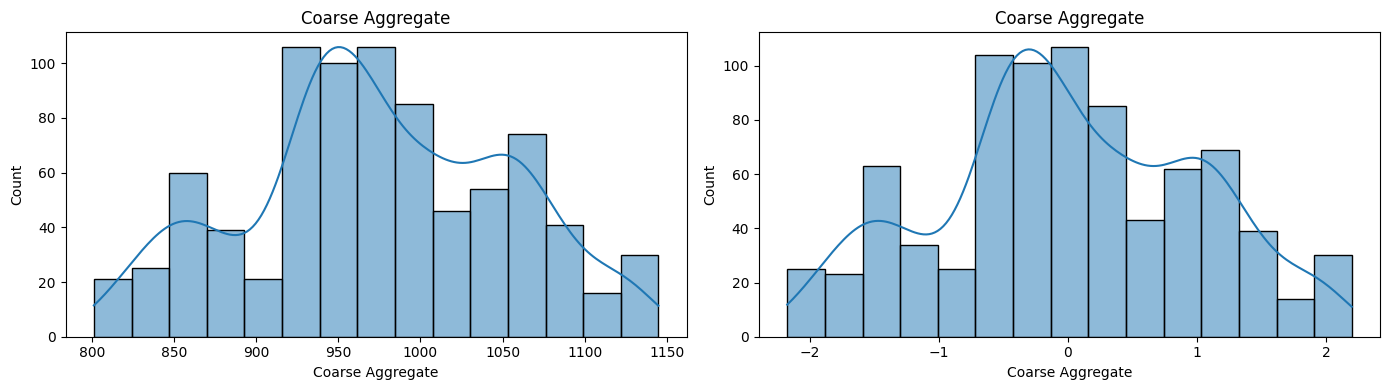

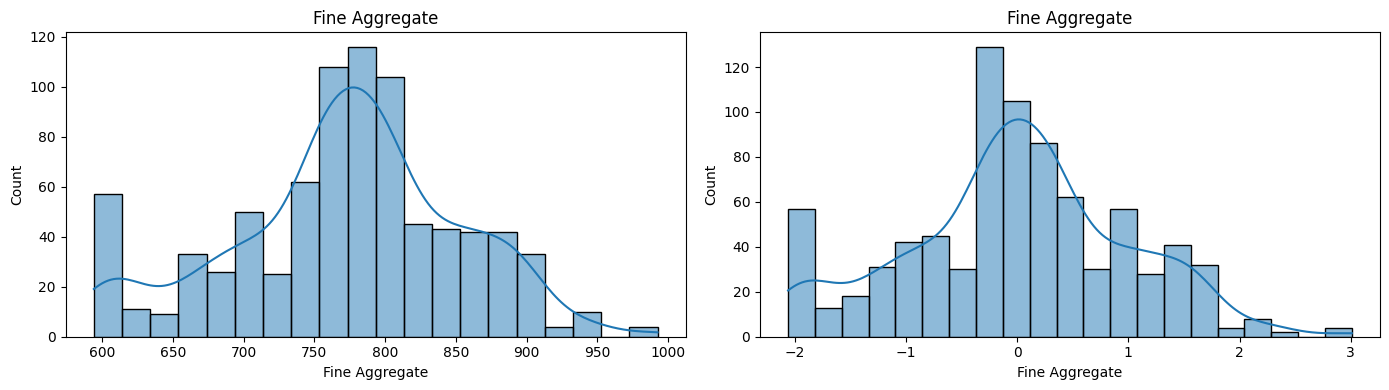

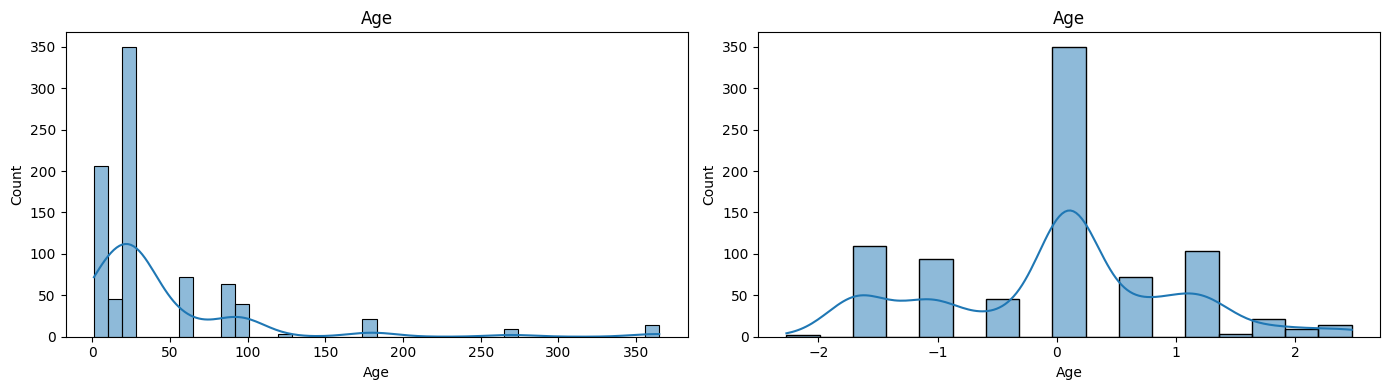

In [27]:
# Before and After comparison for Yeo-Johnson transformation
X_train_transformed2 = pd.DataFrame(X_train_transformed2,columns=X_train.columns)

for col in X_train_transformed2.columns:

    plt.figure(figsize=(14,4))
    # before plot i.e first plot
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True)
    plt.title(col)

    # 2nd plot i.e after plot
    plt.subplot(122)
    sns.histplot(X_train_transformed2[col],kde=True)
    plt.title(col)

    plt.tight_layout()
    plt.show()

### side by side lambdas comparison of both box-cox and yeo-johnson tranformer

In [30]:
pd.DataFrame(
    {
        "cols":X_train.columns,
        "box-cox-lambdas":pt1.lambdas_,
        'yeo-johnson-lambdas':pt2.lambdas_
    }
)

,cols,box-cox-lambdas,yeo-johnson-lambdas
0,Cement,0.172271,0.174348
1,Blast Furnace Slag,0.025273,0.015715
2,Fly Ash,-0.032412,-0.161447
3,Water,0.809568,0.771307
4,Superplasticizer,0.099711,0.253935
5,Coarse Aggregate,1.129168,1.130050
6,Fine Aggregate,1.829625,1.783100
7,Age,0.048975,0.019885
